# 2.12 — Données déséquilibrées : la courbe PR, les stratégies de rééchantillonnage et le seuil qui coûte

**Navigation** : [<< 2.5-Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook [2.5](2.5-Biais-Variance-CV-ROC.ipynb) a montré que la courbe ROC et l'**AUC** jugent un classifieur au-delà de la seule accuracy. Mais quand la classe qui nous intéresse est **rare**, la ROC devient une alliée trompeuse : sur un jeu à ~2 % de positifs, un modèle qui ne prédit presque jamais positif garde une AUC respectable, car le **taux de faux positifs reste bas par construction** — il n'y a quasiment pas de vrai positif à trouver. La **courbe Precision-Recall** est alors la métrique honnête : elle rend visible qu'à l'usage le classifieur ne retrouve presque aucun des cas rares.

C'est la réalité de nos publics : détection d'anomalies, défaut de crédit, régimes de marché rares, fraude — partout la classe intéressante est la plus rare et la plus coûteuse à rater. Ce notebook fabrique un jeu à ~3 % de positifs et déroule le geste complet : rendre le problème visible, confronter ROC et PR, comparer quatre stratégies de rééchantillonnage, choisir un seuil par le **coût**, et éviter le **piège de fuite** de SMOTE appliqué avant la séparation train/test.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. Expliquer pourquoi l'accuracy ment quand la classe positive est rare (le « paradoxe de l'accuracy »).
2. Confronter une courbe ROC et une courbe Precision-Recall sur le même modèle et dire ce que la seconde révèle.
3. Comparer quatre stratégies (classe pondérée, sous-échantillonnage, sur-échantillonnage, SMOTE) sur le même protocole multi-seed, sans croire qu'aucune ne domine partout.
4. Choisir un **seuil** qui minimise le coût attendu, étant donné un ratio explicite coût-faux-négatif / coût-faux-positif.
5. Identifier et corriger la fuite « SMOTE avant le split » — ni plus ni moins.


In [1]:
import warnings
def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"
warnings.formatwarning = _warn_no_path
# Configuration et imports pour le notebook 2.12
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)
print("Configuration OK : 2.12 - Donnees desequilibrees")


Configuration OK : 2.12 - Donnees desequilibrees


## 1. Le paradoxe de l'accuracy : la classe rare rend la métrique aveugle

Un classifieur qui **ignore la classe rare** et prédit toujours la classe majoritaire obtient une accuracy impressionnante. C'est un « excellent » score pour un modèle inutilisable : il ne détecte **aucun** des cas qui comptent. On fabrique ce cas de figure : un jeu binaire où les positifs ne représentent qu'environ 3 % de l'échantillon.


In [2]:
# Dataset binaire fortement desequilibre : environ 3% de positifs
X, y = make_classification(n_samples=4000, n_features=20, n_informative=8,
                           n_redundant=2, weights=[0.97, 0.03],
                           random_state=42)
print("Proportion de positifs :", f"{y.mean():.3f}")

# Le classifieur naif "predire toujours 0" : accuracy elevee, rappel nul
y_pred_zero = np.zeros_like(y)
print("Accuracy du 'toujours 0' :", f"{accuracy_score(y, y_pred_zero):.3f}")
print("Rappel de la classe 1    :", f"{recall_score(y, y_pred_zero):.3f}")


Proportion de positifs : 0.034
Accuracy du 'toujours 0' : 0.966
Rappel de la classe 1    : 0.000


### Lecture du résultat

Le classifieur naïf atteint une accuracy de **96,6 %** (rendu `0.966`) — impressionnante au premier regard — tout en échouant à détecter **le moindre cas positif** (rappel `0.000`). L'accuracy est ici dominée par la classe majoritaire : elle ne mesure pas ce qui nous intéresse. C'est le point de départ de tout le reste du notebook : sur une classe rare, il faut des métriques qui regardent la **classe positive**, et un **seuil** choisi pour ce que coûte une erreur.


### Exercice 1 : le geste de mesure sur une classe rare

Une matrice de confusion ne se lit pas d'un bloc : sur une classe rare, l'accuracy ment (section 1) et ce sont la **précision** et le **rappel** qui disent si le modèle sert à quelque chose. On pose une matrice de confusion fictive et on calcule les trois métriques à la main.

Données : sur 1000 tests dont **30** positifs, un modèle prédit `TP = 12`, `FP = 60` (fausses alertes), `FN = 18` (positifs ratés), `TN = 910`.

Indices :
- # Étape 1 : `precision = TP / (TP + FP)` — parmi les alertes, combien sont vraies.
- # Étape 2 : `rappel = TP / (TP + FN)` — parmi les positifs réels, combien sont retrouvés.
- # Étape 3 : `f1 = 2 * precision * rappel / (precision + rappel)` — le compromis harmonique.


In [3]:
# Exercice 1 : calculer precision, rappel et F1 depuis une matrice de confusion
TP = 12; FP = 60; FN = 18; TN = 910

precision = None  # TODO etudiant : TP / (TP + FP)
rappel = None     # TODO etudiant : TP / (TP + FN)
f1 = None         # TODO etudiant : 2 * precision * rappel / (precision + rappel)
if precision is not None and rappel is not None and (precision + rappel) > 0:
    f1 = 2 * precision * rappel / (precision + rappel)

print(f"Exercice 1 a completer : precision = {precision}, rappel = {rappel}, f1 = {f1}")


Exercice 1 a completer : precision = None, rappel = None, f1 = None


## 2. ROC vs PR : quand la courbe ROC flatte et que la PR dit la vérité

On entraîne un vrai modèle (régression logistique) sur ces données déséquilibrées et on trace **les deux courbes sur le même test**, côte à côte : la courbe ROC à gauche, la courbe Precision-Recall à droite. Sur un jeu à ~3 % de positifs, la ROC et la PR racontent deux histoires différentes.


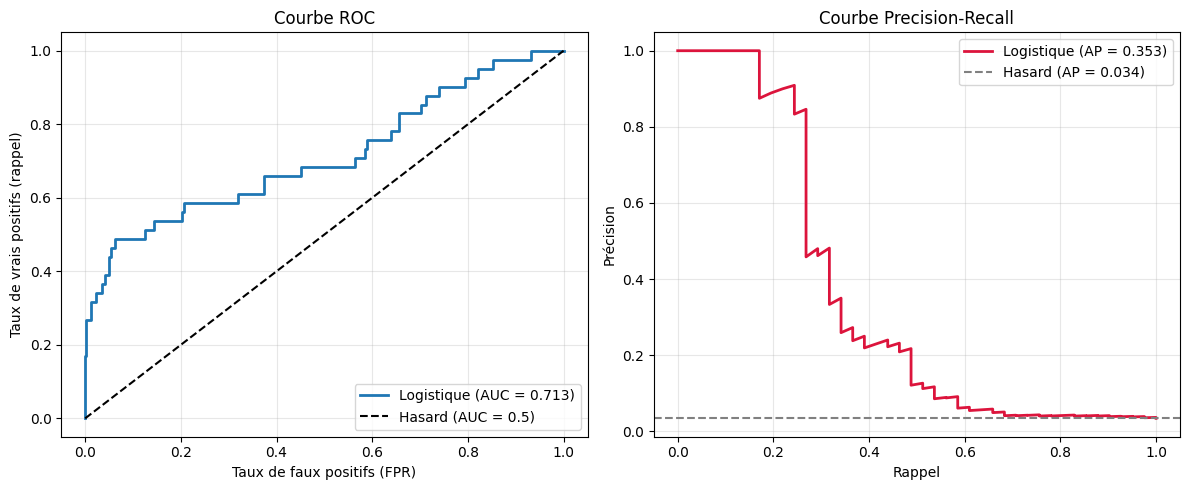

AUC-ROC = 0.713   Average Precision = 0.353
Seuil 0.5 -> precision = 1.000, rappel = 0.098


In [4]:
# Un modele reel (regression logistique) sur les memes donnees desequilibrees
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)
clf = Pipeline([("scaler", StandardScaler()),
                ("lr", LogisticRegression(max_iter=2000))])
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

# Courbe Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, linewidth=2, label=f"Logistique (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
axes[0].set_xlabel("Taux de faux positifs (FPR)")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, linewidth=2, color="crimson",
             label=f"Logistique (AP = {ap:.3f})")
axes[1].axhline(y_test.mean(), color="gray", ls="--",
                label=f"Hasard (AP = {y_test.mean():.3f})")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Precision-Recall")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

y_pred_05 = (proba >= 0.5).astype(int)
print(f"AUC-ROC = {auc:.3f}   Average Precision = {ap:.3f}")
print(f"Seuil 0.5 -> precision = {precision_score(y_test, y_pred_05):.3f}, "
      f"rappel = {recall_score(y_test, y_pred_05):.3f}")


### Lecture du résultat

L'**AUC-ROC** reste élevée (`0.713`) : le taux de faux positifs demeure faible *parce qu'il y a très peu de vrais positifs*. L'**average precision** (« combien de prédictions positives sont réellement correctes ») est bien plus modeste (`0.353`), et la courbe PR chute vite dès qu'on exige un rappel raisonnable. La **baseline** (la ligne grise : précision = proportion de positifs, `0.034`) est la barre du hasard : la courbe PR montre l'écart *réel* au hasard, la ROC le masque.


## 3. Quatre stratégies de rééchantillonnage comparées sur le même protocole

Face au déséquilibre, le réflexe est de **rééquilibrer** : pondérer les classes, sous-échantillonner la classe majoritaire, sur-échantillonner la minoritaire, ou **SMOTE** (générer des positifs synthétiques par interpolation entre voisins). On compare les cinq (baseline comprise) sur **le même protocole multi-seed** : chaque stratégie est refittée sur plusieurs graines de séparation train/test, et on moyenne les métriques. On garde la leçon d'honnêteté : **aucune stratégie ne domine partout** — tout dépend du coût relatif d'un faux négatif face à un faux positif.


In [5]:
# Fabrique une pipeline par strategie (helper pour eviter la duplication)
def _build_pipe(mode, seed):
    if mode is None:
        return Pipeline([("scaler", StandardScaler()),
                         ("lr", LogisticRegression(max_iter=2000))])
    if mode == "weighted":
        return Pipeline([("scaler", StandardScaler()),
                         ("lr", LogisticRegression(max_iter=2000,
                                                   class_weight={0: 1, 1: 33}))])
    if mode == "undersample":
        return ImbPipeline([("scaler", StandardScaler()),
                            ("under", RandomUnderSampler(random_state=seed)),
                            ("lr", LogisticRegression(max_iter=2000))])
    if mode == "oversample":
        return ImbPipeline([("scaler", StandardScaler()),
                            ("over", RandomOverSampler(random_state=seed)),
                            ("lr", LogisticRegression(max_iter=2000))])
    if mode == "smote":
        return ImbPipeline([("scaler", StandardScaler()),
                            ("smote", SMOTE(random_state=seed)),
                            ("lr", LogisticRegression(max_iter=2000))])

STRATEGIES = {
    "Rien (baseline)": None,
    "class_weight {0:1, 1:33}": "weighted",
    "Sous-echantillonnage": "undersample",
    "Sur-echantillonnage": "oversample",
    "SMOTE": "smote",
}
seeds = [0, 1, 2, 42]
resultats = []
for nom, mode in STRATEGIES.items():
    aps, precs, recs = [], [], []
    for s in seeds:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                                  random_state=s, stratify=y)
        pipe = _build_pipe(mode, s)
        pipe.fit(X_tr, y_tr)
        proba_te = pipe.predict_proba(X_te)[:, 1]
        aps.append(average_precision_score(y_te, proba_te))
        precs.append(precision_score(y_te, (proba_te >= 0.5).astype(int)))
        recs.append(recall_score(y_te, (proba_te >= 0.5).astype(int)))
    resultats.append({
        "strategie": nom,
        "AP moyen +/- ecart-type": f"{np.mean(aps):.3f} +/- {np.std(aps):.3f}",
        "precision @0.5": f"{np.mean(precs):.3f}",
        "rappel @0.5": f"{np.mean(recs):.3f}",
    })
    print(f"{nom:30s} AP = {np.mean(aps):.3f} +/- {np.std(aps):.3f}  "
          f"(rappel {np.mean(recs):.3f})")

df_res = pd.DataFrame(resultats)
df_res


Rien (baseline)                AP = 0.268 +/- 0.054  (rappel 0.055)
class_weight {0:1, 1:33}       AP = 0.171 +/- 0.048  (rappel 0.665)
Sous-echantillonnage           AP = 0.124 +/- 0.045  (rappel 0.671)
Sur-echantillonnage            AP = 0.173 +/- 0.051  (rappel 0.646)


SMOTE                          AP = 0.173 +/- 0.048  (rappel 0.604)


,strategie,AP moyen +/- ecart-type,precision @0.5,rappel @0.5
0,Rien (baseline),0.268 +/- 0.054,0.917,0.055
1,"class_weight {0:1, 1:33}",0.171 +/- 0.048,0.063,0.665
2,Sous-echantillonnage,0.124 +/- 0.045,0.061,0.671
3,Sur-echantillonnage,0.173 +/- 0.051,0.074,0.646
4,SMOTE,0.173 +/- 0.048,0.071,0.604


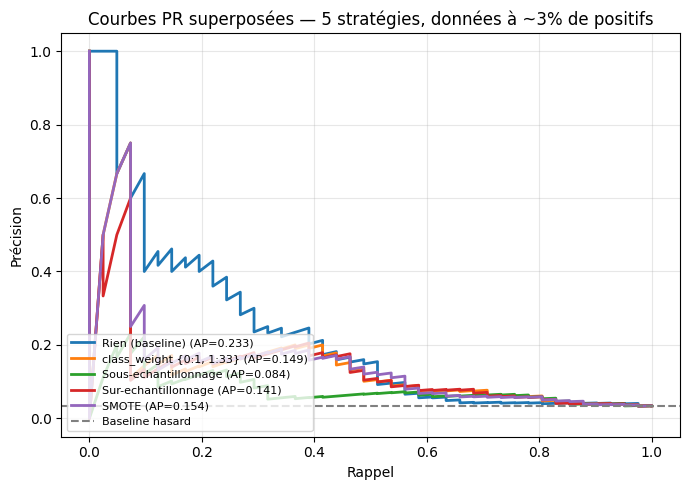

In [6]:
# Courbes PR superposees des 5 strategies, graine representative (seed = 0)
plt.figure(figsize=(7, 5))
for nom, mode in STRATEGIES.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                              random_state=0, stratify=y)
    pipe = _build_pipe(mode, 0)
    pipe.fit(X_tr, y_tr)
    proba_te = pipe.predict_proba(X_te)[:, 1]
    pr, rc, _ = precision_recall_curve(y_te, proba_te)
    ap = average_precision_score(y_te, proba_te)
    plt.plot(rc, pr, linewidth=2, label=f"{nom} (AP={ap:.3f})")

plt.axhline(y_test.mean(), color="gray", ls="--", label="Baseline hasard")
plt.xlabel("Rappel"); plt.ylabel("Précision")
plt.title("Courbes PR superposées — 5 stratégies, données à ~3% de positifs")
plt.legend(loc="lower left", fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Lecture du résultat

Le tableau multi-seed raconte l'arbitrage, et la leçon d'honnêteté est littérale : **aucune stratégie ne domine partout**. La **baseline** (« ne rien faire ») garde la meilleure average precision (`0.268`) et la plus haute précision (`0.917`) — mais seulement **5,5 % de rappel** (`0.055`) : elle ne retrouve presque aucun cas rare. Toutes les stratégies de rééchantillonnage font l'inverse : elles montent le rappel à `0.60-0.67` (class_weight `0.665`, sous-échantillonnage `0.671`, sur-échantillonnage `0.646`, SMOTE `0.604`) en effondrant la précision (`0.06-0.07`) et font même **baisser** l'AP (`0.12-0.17`).

Ce n'est pas un paradoxe : l'AP récompense la précision, or rééquilibrer sacrifie la précision pour le rappel. Si un faux négatif est coûteux (rater une fraude, un défaut), c'est le **rappel** qu'on veut — le sous-échantillonnage (`0.671`) est alors le bon choix, précision basse (`0.061`) assumée. Si le faux positif est le plus coûteux (alertes inutiles), la baseline suffit. Les écarts-types (`±0.045-0.054`) montrent que l'ordre relatif tient sur le protocole multi-seed : la comparaison n'est pas un chiffre instable.

### Exercice 2 : choisir une stratégie selon le coût des erreurs

Le tableau ci-dessus donne la précision et le rappel @0.5 de chaque stratégie. Relevez la stratégie qui maximise le rappel (on veut ne rater aucune fraude), puis celle qui maximise la précision (on veut peu de fausses alertes). Expliquez en une phrase quel **coût** rend chaque choix rationnel et pour quelle stratégie `precision` et `rappel` restent simultanément élevés (le meilleur compromis de ce tableau — ou dites si aucun n'en est un).

Indices :
- # Étape 1 : lire `df_res` (ou les `print` ci-dessus) et repérer les deux extrêmes (rappel max, précision max).
- # Étape 2 : comparer la ligne qui a `precision` ET `rappel` les plus hauts simultanément.
- # Étape 3 : rédiger le coût (coût-FN vs coût-FP) qui justifie chaque choix.


In [7]:
# Exercice 2 : interpreter le tableau multi-seed des strategies
# TODO etudiant : completer les trois variables ci-dessous apres lecture de df_res
strategie_rappel_max = None  # TODO etudiant : remplacer (nom de la strategie a rappel max)
strategie_precision_max = None  # TODO etudiant : remplacer (nom a precision max)
meilleur_compromis = None  # TODO etudiant : remplacer (nom qui garde precision et rappel hauts)
print(f"Exercice 2 a completer : rappel max = {strategie_rappel_max}, precision max = {strategie_precision_max}, compromis = {meilleur_compromis}")


Exercice 2 a completer : rappel max = None, precision max = None, compromis = None


### Lecture du résultat

Le seuil optimal est **`0.21`** (coût attendu minimal `153.0`), pas `0.5` : comme un faux négatif coûte 5× un faux positif, on abaisse le seuil pour prédire « positif » plus souvent — quitte à générer des faux positifs — afin de rater moins de cas rares. À `0.05`, le modèle prédit trop large (`177` faux positifs, coût `272`) ; à `0.5` il rate trop de positifs. Le minimum est un vrai compromis, dicté par la décision économique, pas par une convention. Renverser le ratio (un faux positif coûte plus cher) remonterait le seuil : c'est exactement le geste relié au **choix de seuil par coût** déjà posé par [2.5](2.5-Biais-Variance-CV-ROC.ipynb), et au calcul de *expected value* de la série [DecisionTheory](../../../DecisionTheory/README.md).


In [8]:
# Seuil qui minimise le cout attendu, pour un ratio cout-FN / cout-FP explicite
cout_fn, cout_fp = 5.0, 1.0   # un faux negatif coute 5x un faux positif

seuils_tries = np.linspace(0.05, 0.95, 30)
lignes = []
for t in seuils_tries:
    y_pred = (proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1, 0]   # vrai positif (classe 1) predit 0
    fp = cm[0, 1]   # vrai negatif (classe 0) predit 1
    cout = fp * cout_fp + fn * cout_fn
    lignes.append((t, fp, fn, cout))

df_cout = pd.DataFrame(lignes, columns=["seuil", "faux_positif", "faux_negatif", "cout_attendu"])
i_opt = df_cout["cout_attendu"].idxmin()
print("Seuil optimal (cout attendu minimal) :", f"{df_cout.loc[i_opt, 'seuil']:.2f}")
print("cout attendu minimal :", f"{df_cout.loc[i_opt, 'cout_attendu']:.1f}")
df_cout


Seuil optimal (cout attendu minimal) : 0.21
cout attendu minimal : 153.0


,seuil,faux_positif,faux_negatif,cout_attendu
0,0.050000,177,19,272.0
1,0.081034,66,22,176.0
2,0.112069,36,27,171.0
3,0.143103,23,28,163.0
4,0.174138,10,30,160.0
5,0.205172,3,30,153.0
6,0.236207,1,32,161.0
7,0.267241,1,33,166.0
8,0.298276,1,33,166.0
9,0.329310,0,34,170.0


### Lecture du résultat

Le seuil optimal est **`0.21`** (coût attendu minimal `153.0`), pas `0.5` : comme un faux négatif coûte 5× un faux positif, on abaisse le seuil pour prédire « positif » plus souvent — quitte à générer des faux positifs — afin de rater moins de cas rares. À `0.05`, le modèle prédit trop large (`177` faux positifs, coût `272`) ; à `0.5` il rate trop de positifs. Le minimum est un vrai compromis, dicté par la décision économique, pas par une convention. Renverser le ratio (un faux positif coûte plus cher) remonterait le seuil : c'est exactement le geste relié à la théorie de la décision (valeur attendue avec probabilités calibrées, cf. [2.9](2.9-Grokking-Generalisation.ipynb)) et au calcul de *expected value* de la série [DecisionTheory](../../../DecisionTheory/README.md).


## 5. Le piège de fuite : SMOTE avant le split, l'évaluation est faussée

Le **SMOTE** doit être appliqué dans le pipeline, **après** la séparation train/test. Si on rééquilibre *toutes* les données puis qu'on sépare, les positifs synthétiques générés sur le train **contaminent le test** (et le test, rééquilibré, n'a plus la proportion réelle). On démontre la fuite en comparant deux évaluations.


In [9]:
# Pipelines INCORRECT (SMOTE avant le split) vs CORRECT (SMOTE dans le pipeline)
# INCORRECT : fit_resample sur TOUT X, puis separation sur les donnees resamplees
X_res, y_res = SMOTE(random_state=0).fit_resample(X, y)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_res, y_res, test_size=0.3,
                                                        random_state=0, stratify=y_res)
lr_leak = LogisticRegression(max_iter=2000).fit(Xr_train, yr_train)
proba_leak = lr_leak.predict_proba(Xr_test)[:, 1]
ap_leak = average_precision_score(yr_test, proba_leak)

# CORRECT : le SMOTE vit dans la pipeline, apres le split (il ne voit que le train)
X_trainc, X_testc, y_trainc, y_testc = train_test_split(X, y, test_size=0.3,
                                                        random_state=0, stratify=y)
pipe_correct = ImbPipeline([("scaler", StandardScaler()),
                            ("smote", SMOTE(random_state=0)),
                            ("lr", LogisticRegression(max_iter=2000))])
pipe_correct.fit(X_trainc, y_trainc)
proba_correct = pipe_correct.predict_proba(X_testc)[:, 1]
ap_correct = average_precision_score(y_testc, proba_correct)

print("AP avec SMOTE AVANT le split  :", f"{ap_leak:.3f}")
print("AP avec SMOTE dans le pipeline :", f"{ap_correct:.3f}")
print("Ecart (sur-evaluation de la fuite) :", f"{ap_leak - ap_correct:+.3f}")
print("Proportion de positifs du test INCORRECT (resample) :", f"{yr_test.mean():.3f}")
print("Proportion de positifs du test CORRECT (reel)       :", f"{y_testc.mean():.3f}")


AP avec SMOTE AVANT le split  : 0.804
AP avec SMOTE dans le pipeline : 0.154
Ecart (sur-evaluation de la fuite) : +0.650
Proportion de positifs du test INCORRECT (resample) : 0.500
Proportion de positifs du test CORRECT (reel)       : 0.034


### Lecture du résultat

La version **incorrecte** affiche une average precision **`0.804`** contre **`0.154`** pour la corrigée — soit une **surévaluation de `+0.650`**. Le test incorrect a été rééquilibré : il porte **`50.0 %` de positifs** au lieu des **`3.4 %`** réels, donc l'évaluation est artificiellement facile *et* des positifs synthétiques issus du train (SMOTE appliqué avant le split) se retrouvent dans le test. La version **correcte** — SMOTE dans la pipeline, après le split — évalue sur un test qui reflète la vraie distribution. La leçon tient en une règle : **tout rééchantillonnage s'applique au train uniquement**.

### Exercice 3 (capstone) : réparer un pipeline qui fuit

On vous donne ce fragment *fautif* :
```python
X_res, y_res = SMOTE(random_state=0).fit_resample(X, y)
X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res)
model = LogisticRegression().fit(X_tr, y_tr)
```
Réécrivez-le en une pipeline imblearn correcte, sans rééchantillonner le test.

Indices :
- # Étape 1 : séparer d'abord `train_test_split(X, y, ...)` sur les données **originales**.
- # Étape 2 : placer `SMOTE` dans une `ImbPipeline`, après le scaler, **avant** le classifieur.
- # Étape 3 : `fit` uniquement sur le train ; évaluer sur le test original (jamais resamplé).


In [10]:
# Exercice 3 (capstone) : pipeline imblearn correcte, sans fuite
# TODO etudiant : remplacer les ... par le pipeline correct
# Ordre : scaler -> SMOTE -> logistic regression, applique au TRAIN uniquement
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                          random_state=0, stratify=y)
pipeline_correct = ...  # TODO etudiant : ImbPipeline([...])
print("Exercice 3 a completer : pipeline_correct =", pipeline_correct)


Exercice 3 a completer : pipeline_correct = Ellipsis


## Conclusion et transition

Sur des données déséquilibrées, l'**accuracy est une métrique qui ment** : elle est dominée par la classe majoritaire. Le geste professionnel tient en quatre réflexes, tous démontrés ici : **mesurer avec la courbe PR** (l'average precision, pas l'AUC-ROC seule), **rééquilibrer en connaissance de cause** (aucune stratégie ne domine partout — le bon choix dépend du coût d'un faux négatif face à un faux positif), **choisir le seuil par le coût attendu** plutôt qu'à 0.5, et **confiner le rééchantillonnage au train** (SMOTE avant le split = fuite). Cela prépare directement la détection d'anomalies [QC-Py-24](../../../QuantConnect/Python/QC-Py-24-Anomalie-Autoencodeurs.ipynb) et l'usage de `class_weight` en recherche quant (QC-Py-19) : partout la classe intéressante est rare.


## References

1. Chawla, N.V. et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research 16:321-357. — Le sur-échantillonnage synthétique, et l'obligation de l'appliquer au train seul.
2. Saito, T. & Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets*. PLOS ONE 10(3):e0118432. — Pourquoi la courbe PR est la métrique honnête du déséquilibre.
3. Davis, J. & Goadrich, M. (2006). *The Relationship Between Precision-Recall and ROC Curves*. ICML. — Le lien formel PR/ROC et la domination du second sur données déséquilibrées.
4. Provost, F. & Fawcett, T. (2013). *Data Science for Business*. O'Reilly, ch. 5. — Le coût des erreurs et le choix de seuil comme décision économique.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `roc_curve`, `precision_recall_curve`, `average_precision_score`.
